In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model

In [6]:
aqs = pd.read_csv('C:/Users/mayav/Desktop/GEOL415/LA_AQS_2023.csv')

In [11]:
ml = pd.read_csv('C:/Users/mayav/Desktop/GEOL415/ManuaLoa_CO2.csv')

In [31]:
O3_aqs = aqs[(aqs['Parameter Name']=='Ozone')]

In [32]:
NO2_aqs = aqs[(aqs['Parameter Name']=='Nitrogen dioxide (NO2)')]

In [64]:
O3 = pd.DataFrame(data = {"O3" : (O3_aqs['Arithmetic Mean']* 1e3), 'Time' : (O3_aqs['Date (Local)'])})
NO2 = pd.DataFrame(data = {"NO2" : (NO2_aqs['Arithmetic Mean']), 'Time' : (NO2_aqs['Date (Local)'])})
O3andNO2 = O3.merge(NO2, on=['Time'])

In [ ]:
# finding fit line between O3 and NO2

<Axes: >

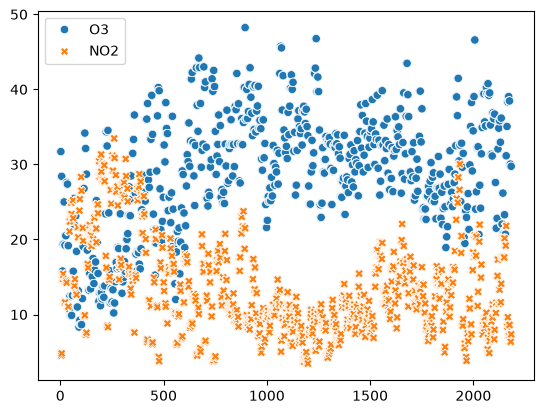

In [65]:
sns.scatterplot(data=(O3andNO2))

In [67]:
print('Type of df: ', type(O3andNO2))

Type of df:  <class 'pandas.DataFrame'>
Type of time:  <class 'pandas.DataFrame'>
Type of concentration:  <class 'pandas.DataFrame'>


In [69]:
xVal = np.array(O3andNO2['O3']).reshape((-1, 1))
yVal = np.array(O3andNO2['NO2'])

reg = linear_model.LinearRegression()
reg.fit(xVal,yVal)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.46]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.56
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[368.64]


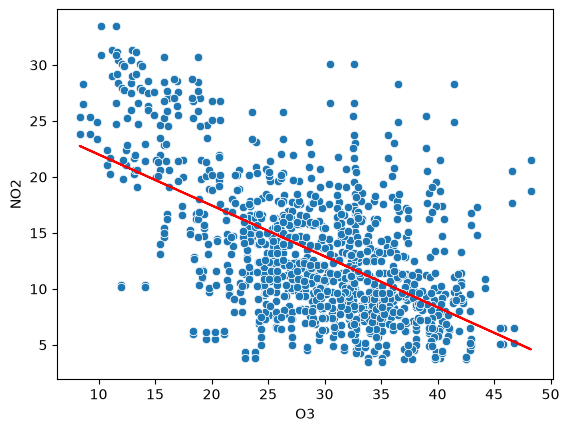

In [73]:
yPred = reg.predict(xVal)

O3andNO2['yPred'] = yPred
sns.scatterplot(data=O3andNO2, x="O3", y="NO2")
plt.plot(O3andNO2['O3'], O3andNO2['yPred'], color='r')

In [76]:
# Mean squared error 
from sklearn.metrics import mean_squared_error
mean_squared_error(O3andNO2['NO2'],O3andNO2['yPred'])

25.627316492427337

In [77]:
# error is ~5 ppm (square root of mean square error)

In [78]:
# test data: train on 80 test on 20

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(xVal, yVal, test_size=0.2)

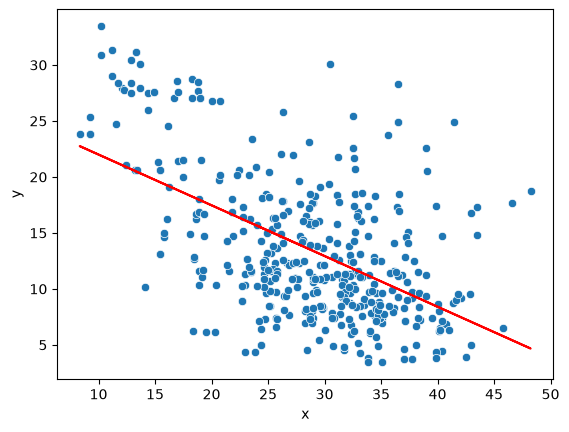

In [83]:
df_test = pd.DataFrame({'x' : X_test.ravel(), 'y' : y_test.ravel()})
df_test['yPred'] = reg2.predict(X_test)

sns.scatterplot(data=df_test, x="x", y="y")
plt.plot(df_test['x'], df_test['yPred'], color='r')

In [84]:
# looks ok!

In [85]:
mean_squared_error(df_test['y'],df_test['yPred'])

28.63528542499815

In [ ]:
# Higher error but that is anticipated, error is ~5.2 ppm (still mean square error method)

In [87]:
reg2 = linear_model.LinearRegression()
reg2.fit(X_train,y_train)
print("Coefficients: \n", reg2.coef_)
print("Intercept: \n", reg2.intercept_)

Coefficients: 
 [-0.45304829]
Intercept: 
 26.528091604702425


In [88]:
print("Coefficients: \n", reg.coef_)
print("Intercept: \n", reg.intercept_)

Coefficients: 
 [-0.45504639]
Intercept: 
 26.560677497509715


In [86]:
# I think this linear model performs well, the mean square errors are close and the parameters on the fit lines are simmilar.
# In this example, I think it is good to use a linear model as there are two variables we are looking at that have a direct relationship to eachother. 
# The linear model helps understand this relationship: as NO2 increases O3 decreases

In [89]:
# MANUA LOA FIT LINE

In [92]:
ml.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


<Axes: xlabel='decimal date', ylabel='average'>

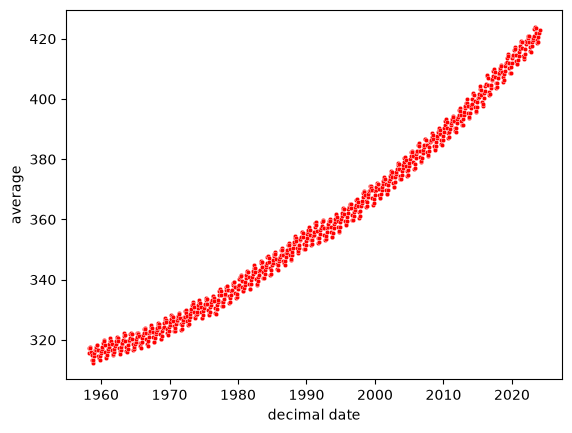

In [90]:
sns.scatterplot(data=ml, x='decimal date', y='average', s=10, color=("red"))

In [113]:
# sort data into training set & testing set

In [114]:
ml['decimal date'] = pd.to_datetime(ml['decimal date'])

In [128]:
ml.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1970-01-01 00:00:00.000001958,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1970-01-01 00:00:00.000001958,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1970-01-01 00:00:00.000001958,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1970-01-01 00:00:00.000001958,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1970-01-01 00:00:00.000001958,315.86,315.18,-1,-9.99,-0.99


In [130]:
mltrain = ml[ml['year']<2000]

In [202]:
mltest = ml[ml['year']>=2000]

In [132]:
mltrain.tail()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
497,1999,8,1970-01-01 00:00:00.000001999,367.06,368.63,25,0.38,0.14
498,1999,9,1970-01-01 00:00:00.000001999,364.95,368.28,28,0.74,0.27
499,1999,10,1970-01-01 00:00:00.000001999,365.52,368.80,31,0.28,0.10
500,1999,11,1970-01-01 00:00:00.000001999,366.88,368.86,28,0.25,0.09
501,1999,12,1970-01-01 00:00:00.000001999,368.26,368.93,26,0.29,0.11


In [139]:
print('Type of df: ', type(mltrain))
print('Type of df[x]: ', type(mltrain['decimal date']))
print('Type of df[y]: ', type(mltrain['average']))

Type of df:  <class 'pandas.DataFrame'>
Type of df[x]:  <class 'pandas.Series'>
Type of df[y]:  <class 'pandas.Series'>


In [186]:
mltrainx = pd.array(mltrain['decimal date']).reshape(-1,1).astype(int)/1**9
mltrainy = pd.array(mltrain['average']).reshape(-1,1)

In [189]:
mltestx = pd.array(mltest['decimal date']).reshape(-1,1).astype(int)/1**9
mltesty = pd.array(mltest['average']).reshape(-1,1)

In [190]:
regml = linear_model.LinearRegression()
regml.fit(mltrainx,mltrainy)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.33]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-2284.6]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[270.56]


In [193]:
yPred = regml.predict(mltrainx)

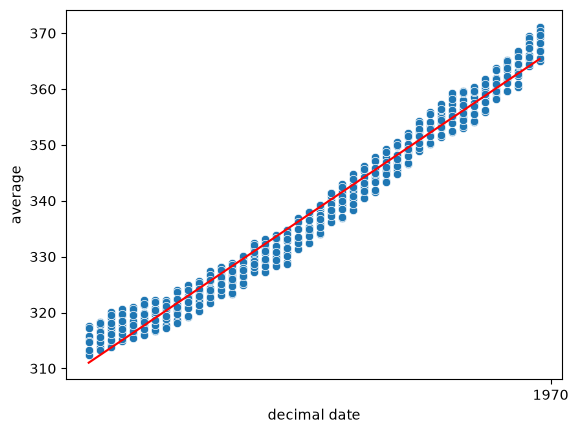

In [197]:
mltrain['yPred'] = yPred
sns.scatterplot(data=mltrain, x=mltrain["decimal date"], y=mltrain["average"])
plt.plot(mltrain['decimal date'], mltrain['yPred'], color='r')

In [200]:
yPred = regml.predict(mltestx)

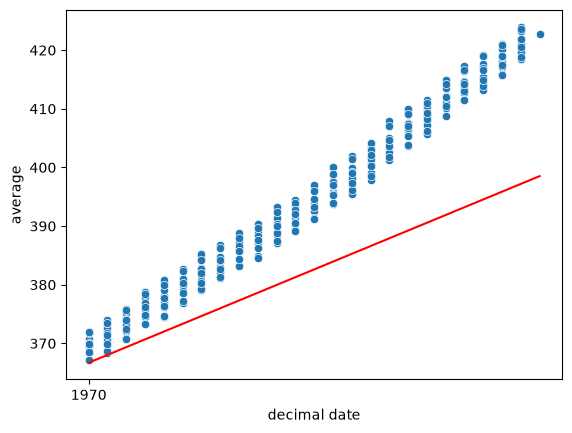

In [204]:
mltest['yPred'] = yPred
sns.scatterplot(data=mltest, x=mltest["decimal date"], y=mltest["average"])
plt.plot(mltest['decimal date'], mltest['yPred'], color='r')

In [ ]:
# The linear regression model does not work well to predict CO2
# Emmisions are not increasing linearly thus we cannot predict them using a linear model.